# Medusa Accepted Tokens and Throughput Analysis

In [31]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('bench_csvs/medusa')
PATTERN = re.compile(r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n128\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if TARGET_COL not in df.columns:
        continue

    # Ignore sentinel values from non-decode steps.
    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]
    mean_val = float(vals.mean()) if len(vals) else np.nan

    records.append({'bs': bs, 'c1': c1, 'c2': c2, 'mean_tokens_accepted_per_seq': mean_val})

agg = pd.DataFrame(records)
if agg.empty:
    raise RuntimeError('No MEDUSA CSVs with the target column were found.')

batch_sizes = sorted(agg['bs'].unique())
n = len(batch_sizes)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

vmin = agg['mean_tokens_accepted_per_seq'].min()
vmax = agg['mean_tokens_accepted_per_seq'].max()

im = None
for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    sub = agg[agg['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values='mean_tokens_accepted_per_seq').reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im = ax.imshow(mat.values, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

if im is not None:
    cbar = fig.colorbar(im, ax=axes[:n], shrink=0.9)
    cbar.set_label('Mean tokens accepted per seq')

fig.suptitle('MEDUSA: Mean Accepted Tokens per Seq by (c1, c2) and Batch Size', fontsize=14)
plt.show()

#agg.sort_values(['bs', 'c1', 'c2']).head()

RuntimeError: No MEDUSA CSVs with the target column were found.

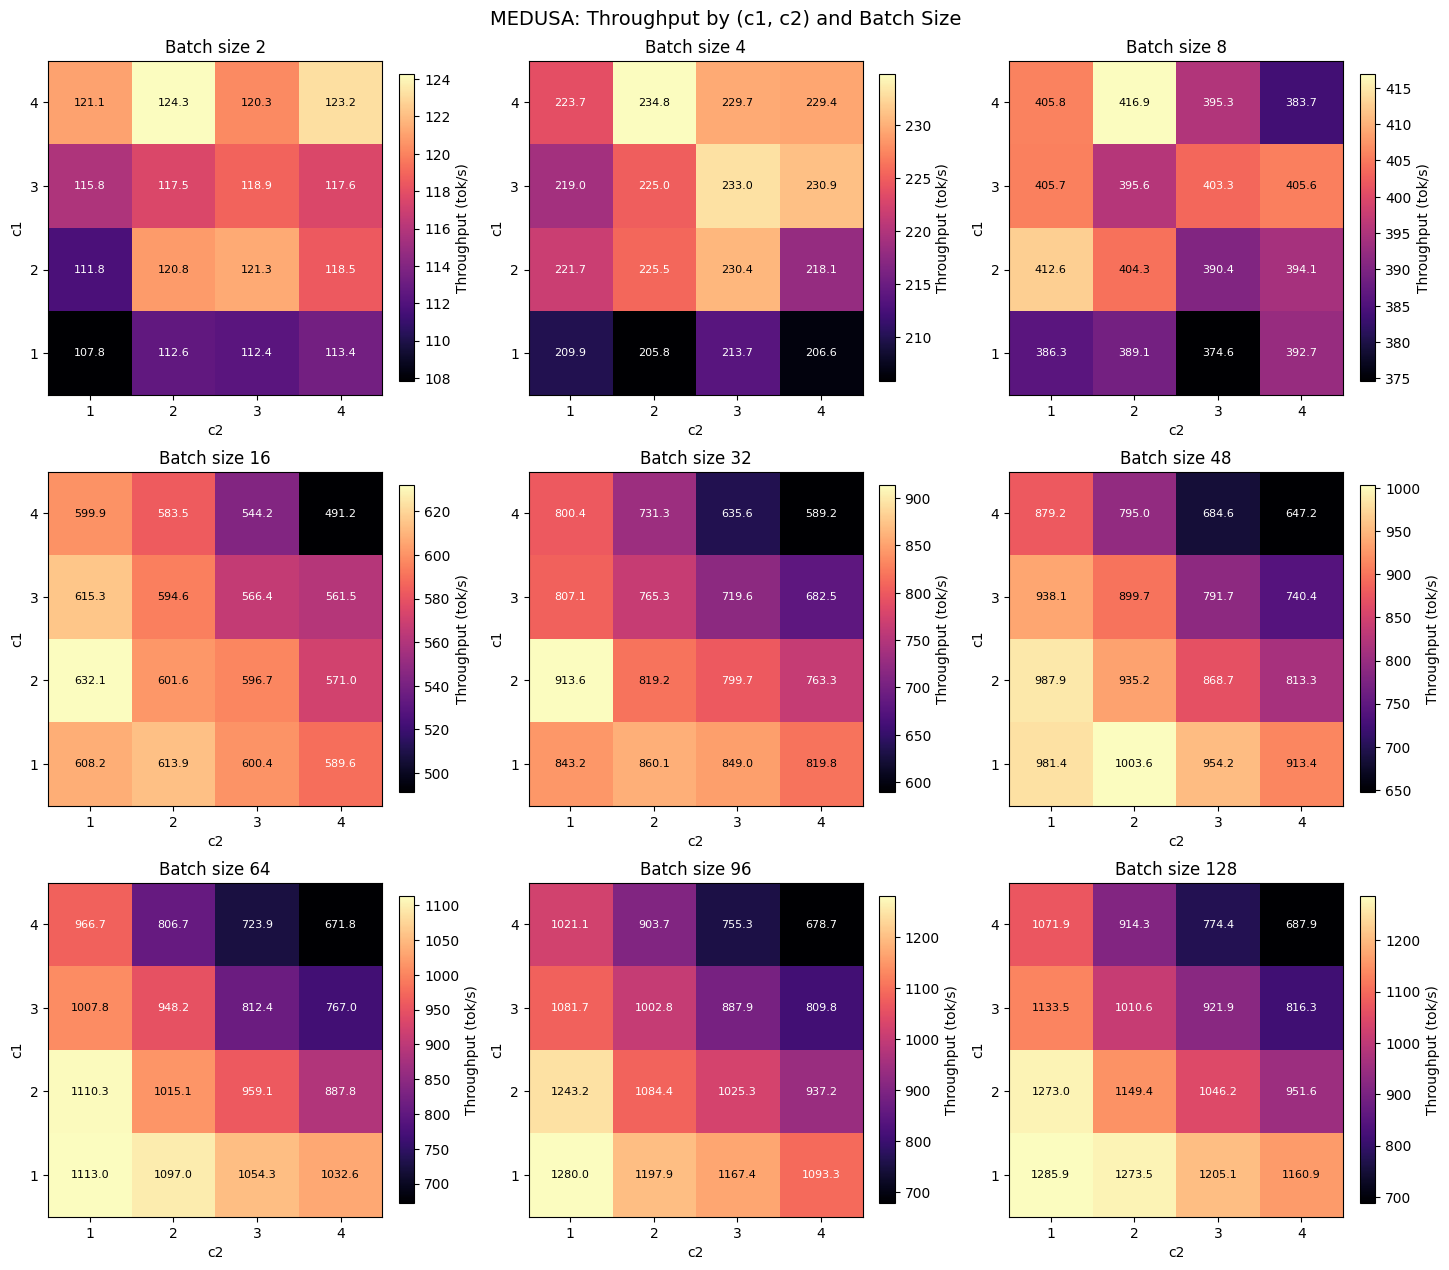

In [ ]:
# Throughput heatmaps by batch size (computed from timestamps and total tokens)

THROUGHPUT_COL = 'throughput_tok_s'

t_records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if 'total_generated_tokens' not in df.columns or 'timestamp' not in df.columns or df.empty:
        continue

    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        continue

    t0 = float(ts.iloc[0])
    t1 = float(ts.iloc[-1])
    total = float(tg.iloc[-1])

    elapsed = t1 - t0
    throughput = (total / elapsed) if elapsed > 0 else np.nan

    t_records.append({'bs': bs, 'c1': c1, 'c2': c2, THROUGHPUT_COL: throughput})

thr = pd.DataFrame(t_records)
if thr.empty:
    raise RuntimeError('No MEDUSA CSVs with timestamp/total_generated_tokens were found.')

batch_sizes_t = sorted(thr['bs'].unique())
n_t = len(batch_sizes_t)
ncols_t = 3
nrows_t = (n_t + ncols_t - 1) // ncols_t

fig, axes = plt.subplots(nrows_t, ncols_t, figsize=(4.8 * ncols_t, 4.2 * nrows_t), constrained_layout=True)
axes = np.array(axes).reshape(-1)

im_t = None
for i, bs in enumerate(batch_sizes_t):
    ax = axes[i]
    sub = thr[thr['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values=THROUGHPUT_COL).reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im_t = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im_t.cmap(im_t.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, bs in enumerate(batch_sizes_t):
    if i < len(axes) and axes[i].images:
        cbar = fig.colorbar(axes[i].images[0], ax=axes[i], shrink=0.9)
        cbar.set_label('Throughput (tok/s)')

fig.suptitle('MEDUSA: Throughput by (c1, c2) and Batch Size', fontsize=14)
plt.show()

#thr.sort_values(['bs', 'c1', 'c2']).head()


# Naive SpecDec vs No SpecDec Throughput Curves

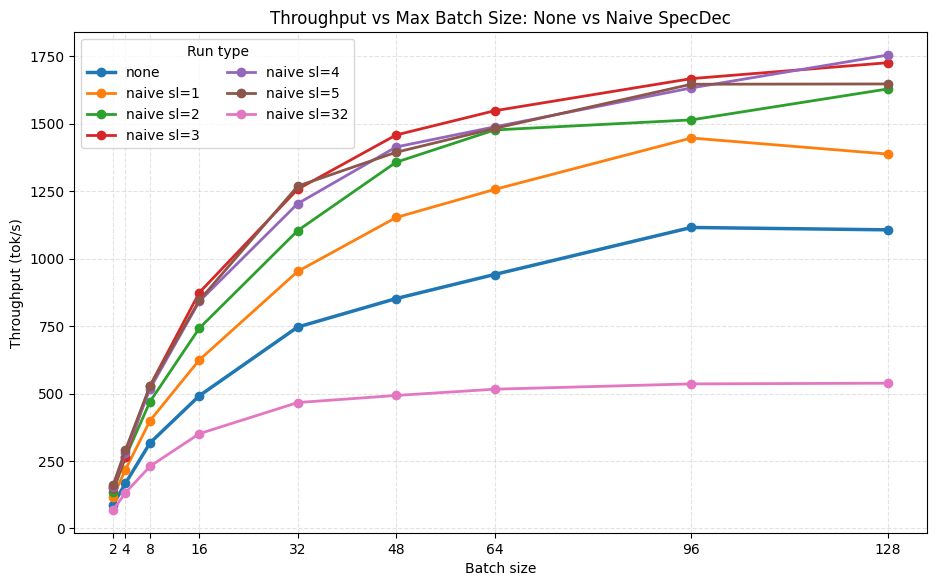

In [4]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NONE_DIR = Path('bench_csvs/none')
NAIVE_DIR = Path('bench_csvs/naive')

pat_none = re.compile(r'^none-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []

for p in sorted(NONE_DIR.glob('none-bs_*-n128-*.data.csv')):
    m = pat_none.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'none', 'spec_len': 0, 'bs': bs, 'throughput': thr, 'file': p.name})

for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    sl = int(m.group('sl'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'naive', 'spec_len': sl, 'bs': bs, 'throughput': thr, 'file': p.name})

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    raise RuntimeError('No none/naive benchmark CSVs found.')

plot_df = plot_df.sort_values(['method', 'spec_len', 'bs'])

fig, ax = plt.subplots(figsize=(11, 6.5))

none_df = plot_df[plot_df['method'] == 'none'].sort_values('bs')
ax.plot(
    none_df['bs'],
    none_df['throughput'],
    marker='o',
    linewidth=2.5,
    label='none',
)

for sl in sorted(plot_df.loc[plot_df['method'] == 'naive', 'spec_len'].unique()):
    sub = plot_df[(plot_df['method'] == 'naive') & (plot_df['spec_len'] == sl)].sort_values('bs')
    ax.plot(
        sub['bs'],
        sub['throughput'],
        marker='o',
        linewidth=2,
        label=f'naive sl={sl}',
    )

ax.set_xticks(sorted(plot_df['bs'].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Batch size')
ax.set_ylabel('Throughput (tok/s)')
ax.set_title('Throughput vs Max Batch Size: None vs Naive SpecDec')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Run type', ncol=2)
plt.show()

#plot_df[['method', 'spec_len', 'bs', 'throughput']].sort_values(['method', 'spec_len', 'bs'])


# Naive Specdec Rejection probability PDF and CDF and p50, p90, p99 values for the CDF

Using the speclen=32 traces, we generate a PDF and CDF of the rejection probabilities for each step, and report p50, p90, and p99 values for the CDF.

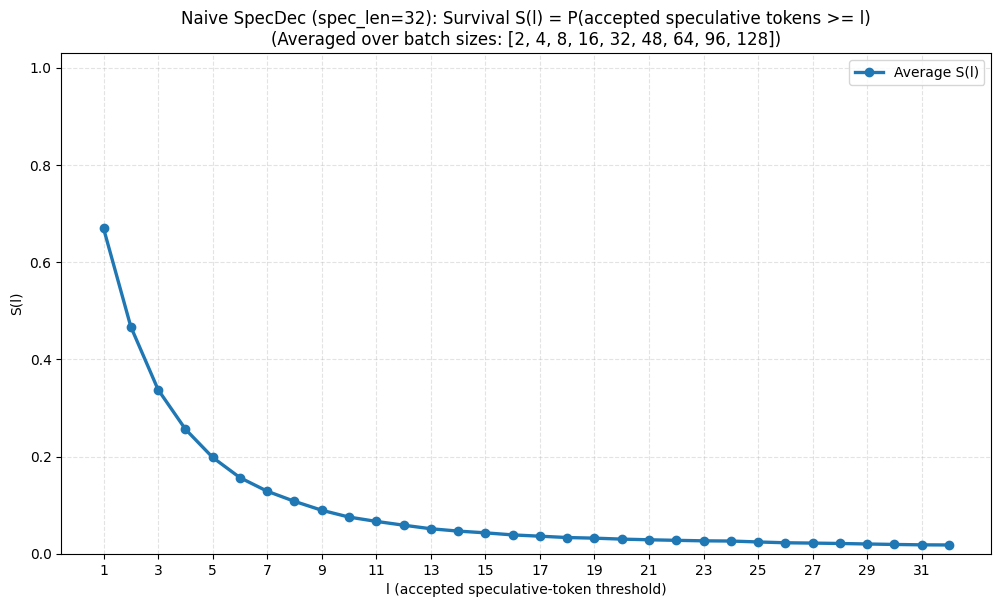

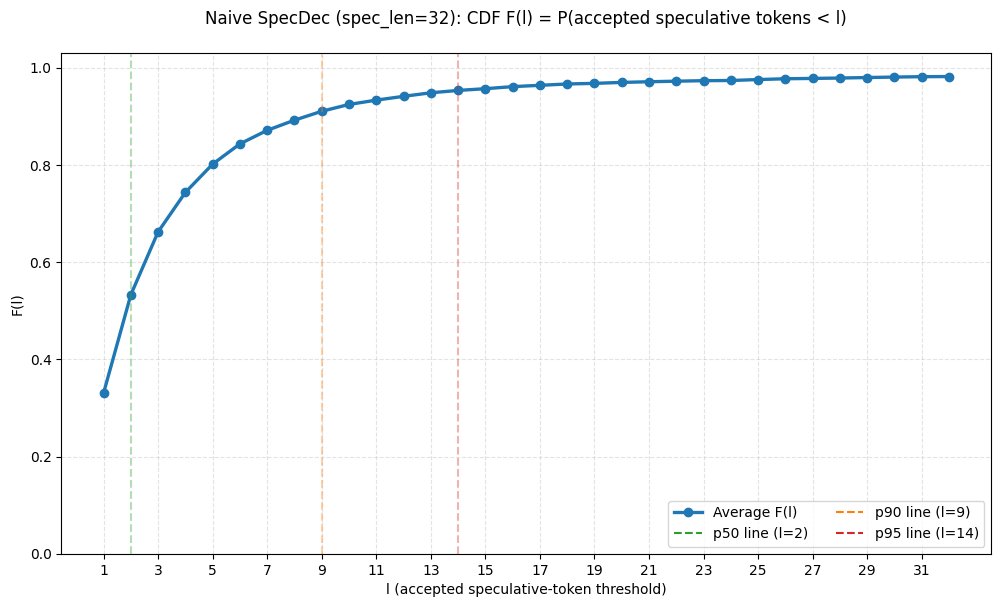

In [22]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NAIVE_DIR = Path('bench_csvs/naive')
PAT = re.compile(r'^naive-speclen_32-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.decode_len_hist\.json$')
SPEC_LEN = 32


def _extract_hist(path: Path) -> tuple[int, dict[int, int]]:
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    acc = payload.get('accepted_spec_tokens', {})
    hist_raw = acc.get('hist', {})
    hist = {int(k): int(v) for k, v in hist_raw.items() if int(v) > 0}
    n = int(acc.get('num_samples', sum(hist.values())))
    if n <= 0:
        n = sum(hist.values())
    return n, hist


def _first_l_for_cdf(values_l: np.ndarray, cdf: np.ndarray, q: float) -> int:
    idx = int(np.searchsorted(cdf, q, side='left'))
    idx = min(max(idx, 0), len(values_l) - 1)
    return int(values_l[idx])


runs = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_32-bs_*-n128-*.decode_len_hist.json')):
    m = PAT.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    n, hist = _extract_hist(p)
    if not hist or n <= 0:
        continue
    runs.append((bs, p.name, n, hist))

if not runs:
    raise RuntimeError('No speclen=32 naive histogram JSONs found with accepted_spec_tokens.')

runs = sorted(runs, key=lambda x: x[0])
ls = np.arange(1, SPEC_LEN + 1, dtype=int)

# Build per-batch survival curves S(l)=P(accepted>=l), then average over batch sizes.
surv_curves = []
for _, _, n, hist in runs:
    surv = np.array([
        sum(hist.get(int(k), 0) for k in range(int(l), SPEC_LEN + 1)) / n
        for l in ls
    ], dtype=float)
    surv_curves.append(surv)

surv_curves = np.array(surv_curves)
surv_avg = np.nanmean(surv_curves, axis=0)
cdf_avg = 1.0 - surv_avg

# Quantiles from averaged CDF.
l50 = _first_l_for_cdf(ls, cdf_avg, 0.50)
l90 = _first_l_for_cdf(ls, cdf_avg, 0.90)
l95 = _first_l_for_cdf(ls, cdf_avg, 0.95)

batch_sizes = [bs for bs, _, _, _ in runs]
label_suffix = f'(Averaged over batch sizes: {batch_sizes})'

# ---- Averaged Survival ----
fig_s, ax_s = plt.subplots(figsize=(12, 6.5))
ax_s.plot(ls, surv_avg, marker='o', linewidth=2.4, color='tab:blue', label='Average S(l)')
ax_s.set_title('Naive SpecDec (spec_len=32): Survival S(l) = P(accepted speculative tokens >= l)\n' + label_suffix)
ax_s.set_xlabel('l (accepted speculative-token threshold)')
ax_s.set_ylabel('S(l)')
ax_s.set_ylim(0.0, 1.03)
ax_s.set_xticks(np.arange(1, SPEC_LEN + 1, 2))
ax_s.grid(True, linestyle='--', alpha=0.35)
ax_s.legend()
plt.show()

# ---- Averaged CDF with quantile lines ----
fig_cdf, ax_cdf = plt.subplots(figsize=(12, 6.5))
ax_cdf.plot(ls, cdf_avg, marker='o', linewidth=2.4, color='tab:blue', label='Average F(l)')

for lv, color in [
    (l50, 'tab:green'),
    (l90, 'tab:orange'),
    (l95, 'tab:red'),
]:
    ax_cdf.axvline(lv, linestyle='--', linewidth=1.5, color=color, alpha=0.35)

quantile_handles = [
    Line2D([0], [0], color='tab:green', linestyle='--', linewidth=1.5, label=f'p50 line (l={l50})'),
    Line2D([0], [0], color='tab:orange', linestyle='--', linewidth=1.5, label=f'p90 line (l={l90})'),
    Line2D([0], [0], color='tab:red', linestyle='--', linewidth=1.5, label=f'p95 line (l={l95})'),
]
curve_handles, curve_labels = ax_cdf.get_legend_handles_labels()
ax_cdf.legend(handles=curve_handles + quantile_handles, ncol=2)

ax_cdf.set_title('Naive SpecDec (spec_len=32): CDF F(l) = P(accepted speculative tokens < l)\n')
ax_cdf.set_xlabel('l (accepted speculative-token threshold)')
ax_cdf.set_ylabel('F(l)')
ax_cdf.set_ylim(0.0, 1.03)
ax_cdf.set_xticks(np.arange(1, SPEC_LEN + 1, 2))
ax_cdf.grid(True, linestyle='--', alpha=0.35)
plt.show()
